#Globals

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

#1. Variational Monte Carlo simulation of a Helium atom

##Commons

In [ ]:
def init():
  r1_vec = np.random.uniform(-0.5,0.5,3)
  r2_vec = np.random.uniform(-0.5,0.5,3)

  r1_norm = np.linalg.norm(r1_vec)
  r2_norm = np.linalg.norm(r2_vec)

  r12_vec = r1_vec - r2_vec
  r12_norm = np.linalg.norm(r12_vec)

  positions = np.array([[r1_vec, r1_norm], [r2_vec, r2_norm]], dtype='object')
  dist = [r12_vec, r12_norm]

  return [positions, dist]

In [ ]:
def take_a_step(walker, s):
  np.random.shuffle(walker[0])
  positions, dist = walker
  r, r_other = positions
  dist_vec, dist_norm = dist

  r_vec, r_norm = r
  r_other_vec, r_other_norm = r_other

  r_proposed_vec = r_vec + np.random.uniform(-0.5*s,0.5*s,3)
  r_proposed_norm = np.linalg.norm(r_proposed_vec)

  dist_proposed_vec = r_proposed_vec - r_other_vec
  dist_proposed_norm = np.linalg.norm(dist_proposed_vec)


  p = np.exp(\
      -2 * (\
            k*(r_proposed_norm - r_norm) \
            + B * (\
                   dist_proposed_norm / (1+A*dist_proposed_norm) \
                   - dist_norm / (1+A*dist_norm)\
                   )
           )\
    )
  random_comparand = np.random.random()

  if ((random_comparand < p) and (p < 1)) or (p >= 1):
    # print('accepted new position')
    positions[0] = [r_proposed_vec, r_proposed_norm]
    dist = [dist_proposed_vec, dist_proposed_norm]
  # else:
    # print('rej new position')

In [ ]:
def take_a_FP_step(walker, s, t_step=1, A=0, B=0, k=0):
  positions, dist = walker
  r1, r2 = positions
  dist_vec, dist_norm = dist

  r1_vec, r1_norm = r1
  r2_vec, r2_norm = r2

  r1_proposed_vec = r1_vec + np.random.uniform(-0.5*s,0.5*s,3) - 2*(B/(dist_norm*(1+A*dist_norm)**2) - k*dist_norm)*r1_vec*t_step
  r1_proposed_norm = np.linalg.norm(r1_proposed_vec)

  r2_proposed_vec = r2_vec + np.random.uniform(-0.5*s,0.5*s,3) - 2*(B/(dist_norm*(1+A*dist_norm)**2) - k*dist_norm)*r2_vec*t_step
  r2_proposed_norm = np.linalg.norm(r2_proposed_vec)

  dist_proposed_vec = r1_proposed_vec - r2_proposed_vec
  dist_proposed_norm = np.linalg.norm(dist_proposed_vec)


  p = np.exp(
      -2 * (
            k*(r1_proposed_norm - r1_norm) \
            + k*(r2_proposed_norm - r2_norm) \
            + B * (\
                   dist_proposed_norm / (1+A*dist_proposed_norm) \
                   - dist_norm / (1+A*dist_norm)\
                   )
           )\
    )
  random_comparand = np.random.random()

  if ((random_comparand < p) and (p < 1)) or (p >= 1):
    positions[0] = [r1_proposed_vec, r1_proposed_norm]
    positions[0] = [r2_proposed_vec, r2_proposed_norm]
    dist = [dist_proposed_vec, dist_proposed_norm]

  # print(f'r_norm = {positions[0][1]}')
  # print(f'r_other_norm = {r_other_norm}')

In [ ]:
def calculate_E_l(A, k, B, positions, dist):
  r1, r2 = positions
  r1_vec, r1_norm = r1
  r2_vec, r2_norm = r2

  dist_vec, dist_norm = dist

  u = 1 + A*dist_norm

  E_l = (k-2)*(1/r1_norm + 1/r2_norm) + 1/dist_norm*(1-2*B/u**2) + 2*B*A/u**3 \
        - k**2 - B**2/u**4 \
        + k*B/u**2*np.dot((r1_vec/r1_norm - r2_vec/r2_norm), dist_vec/dist_norm)

  return E_l

In [ ]:
def simulate_excluding_equil_basic(N, A, s, k, B, n_rec, n_eq = 0):
  walkers = [init() for i in range(M)]
  E_l_walker_sums = np.zeros(M)
  E_l_n_total = []
  var_E_l_n = []

  n = n_rec - n_eq

  for i in range(n_eq):
    clear_output(wait=True)
    print(f'step #{i} bef equil')
    for w in range(M):
      walker = walkers[w]
      take_a_step(walker, s)

  for i in range(n_eq, N):
    clear_output(wait=True)
    print(f'step #{i} after equil')
    for w in range(M):
      walker = walkers[w]
      take_a_step(walker, s)

      E_l_walker_sums[w] += (calculate_E_l(A, k, B, *walker))

    if i%n_rec == 0:
      E_l_n_total.append(np.mean(E_l_walker_sums)/(n_rec))

      var_E_l_n.append(
          np.mean(np.square(E_l_walker_sums)) / n_rec**2 - (np.mean(E_l_walker_sums)/n_rec)**2/M
      )
      E_l_walker_sums = np.zeros(M)

  standard_error = np.sqrt(var_E_l_n)/np.sqrt(M-1)

  return  E_l_n_total, standard_error

In [ ]:
def simulate_excluding_equil(N, A, s, k, B, n_rec, n_eq = 0, FPD=0, t_step=1):
  walkers = [init() for i in range(M)]
  E_l_walker_sums = np.zeros(M)
  E_l_n_total = []
  var_E_l_n = []

  n = n_rec - n_eq

  for i in range(n_eq):
    clear_output(wait=True)
    # print(f'step #{i} bef equil')
    for w in range(M):
      walker = walkers[w]
      if not FPD:
        # np.random.shuffle(walker[0])
        take_a_step(walker, s)
      else:
        take_a_FP_step(walker, s, t_step, A, B, k)

  for i in range(n_eq, N):
    clear_output(wait=True)
    # print(f'step #{i} after equil')
    for w in range(M):
      walker = walkers[w]
      if not FPD:
        take_a_step(walker, s)
      else:
        take_a_FP_step(walker, s, FPD, t_step, A, B, k)

      E_l_walker_sums[w] += (calculate_E_l(A, k, B, *walker))

    if i%n_rec == 0:
      E_l_n_total.append(np.mean(E_l_walker_sums)/(n_rec))

      var_E_l_n.append(
          np.mean(np.square(E_l_walker_sums)) / n_rec**2 - (np.mean(E_l_walker_sums)/n_rec)**2/M
      )
      E_l_walker_sums = np.zeros(M)

  standard_error = np.sqrt(var_E_l_n)/np.sqrt(M-1)

  return  E_l_n_total, standard_error

In [ ]:
def simulate_and_plot(N, A, s, k, B, n_rec, n_eq = 0):
  E_l_n_total, standard_error = simulate_excluding_equil(
      N,
      A,
      s,
      k,
      B,
      n_rec,
      n_eq
  )
  print(f'σ⟨ELn ⟩ after the simulation = {standard_error[-1]}')

  n = n_rec - n_eq

  plt.errorbar(np.arange(n_rec,N,n)/n_rec, E_l_n_total[1:], standard_error[1:])
  plt.ylabel('⟨E_L_n⟩')
  plt.xlabel('n')
  plt.title(f'⟨E_L_n⟩ VS n for s = {s}')


  return E_l_n_total, standard_error

In [ ]:
def simulate_and_plot_basic(N, A, s, k, B, n_rec, n_eq = 0):
  E_l_n_total, standard_error = simulate_excluding_equil_basic(
      N,
      A,
      s,
      k,
      B,
      n_rec,
      n_eq
  )
  print(f'σ⟨ELn ⟩ after the simulation = {standard_error[-1]}')

  n = n_rec - n_eq

  plt.errorbar(np.arange(n_rec,N,n)/n_rec, E_l_n_total[1:], standard_error[1:])
  plt.ylabel('⟨E_L_n⟩')
  plt.xlabel('n')
  plt.title(f'⟨E_L_n⟩ VS n for s = {s} and α = f{A}')


  return E_l_n_total, standard_error

In [ ]:
M = 300

##a

In [ ]:
A  = 0.15
N = 30000
k = 2
B = 0.5
n_rec = 1000

###s = 0.1

In [ ]:
M = 300
s01 = 0.1
E_l_n_total_s01, standard_error_s01 = simulate_and_plot_basic(N, A, s01, k, B, n_rec)

step #33 after equil


KeyboardInterrupt: 

###s = 1

In [ ]:
s1 = 1
E_l_n_total_s1, standard_error_s1 = simulate_and_plot_basic(N, A, s1, k, B, n_rec)

step #3320 after equil


KeyboardInterrupt: 

###s = 10

In [ ]:
s10 = 10
E_l_n_total_s10, standard_error_s10 = simulate_and_plot(N, A, s10, k, B, n_rec)

##Chosen s = 10

In [ ]:
s = 0.1

##b

In [ ]:
N = 10000

In [ ]:
A_range_b = np.arange(0, 0.6, 0.1)
print(A_range_b)

[0.  0.1 0.2 0.3 0.4 0.5]


In [ ]:
A_range_b = np.arange(0, 0.6, 0.1)
E_l_n_total_A_range_b, standard_error_A_range_b = zip(
    *[
        simulate_excluding_equil_basic(N, A_range_b[i], s, k, B, n_rec)
        for i in range(len(A_range_b))
    ]
)

step #9999 after equil


### α = 0.0

step #9999 after equil
σ⟨ELn ⟩ after the simulation = 0.245442141701061


([-0.004236551370232744,
  -4.2484821836546525,
  -4.25152462802008,
  -4.249349871511284,
  -4.248734780315803,
  -4.250485738302552,
  -4.250435267901987,
  -4.251110446364781,
  -4.24959090194867,
  -4.2510977657057785],
 array([0.00025704, 0.24529179, 0.24546592, 0.24533976, 0.24530439,
        0.24540558, 0.24540288, 0.24544138, 0.24535431, 0.24544214]))

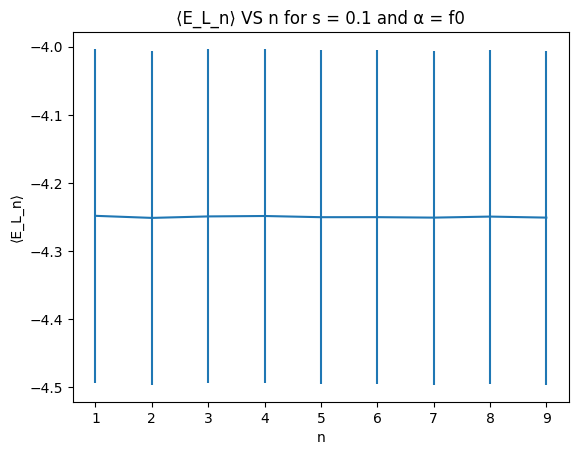

In [ ]:
A0 = 0
simulate_and_plot_basic(N, A0, s, k, B, n_rec)

### α = 0.1

step #9999 after equil
σ⟨ELn ⟩ after the simulation = 0.22705442895206682


([-0.003932522693428188,
  -3.930890909790796,
  -3.9323404590960327,
  -3.930881120050663,
  -3.929723980135182,
  -3.9325288153615237,
  -3.9310718126539776,
  -3.931246598823611,
  -3.931040000694863,
  -3.932644732759455],
 array([0.00023693, 0.22695491, 0.22703789, 0.22695274, 0.2268859 ,
        0.22704815, 0.2269638 , 0.2269744 , 0.22696223, 0.22705443]))

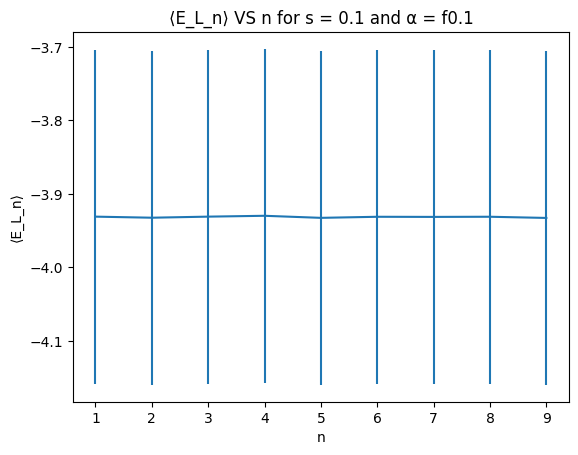

In [ ]:
A01 = 0.1
simulate_and_plot_basic(N, A01, s, k, B, n_rec)

### α = 0.2

step #9999 after equil
σ⟨ELn ⟩ after the simulation = 0.2125232145334937


([-0.00370905354870042,
  -3.6819593450349353,
  -3.683531348744951,
  -3.682546510768098,
  -3.6794885471279564,
  -3.681445297573027,
  -3.680232092048271,
  -3.6836294276506267,
  -3.6829730034274335,
  -3.68093906592795],
 array([0.00022265, 0.21258338, 0.2126721 , 0.21261582, 0.21243896,
        0.21255177, 0.21248266, 0.21267886, 0.21264047, 0.21252321]))

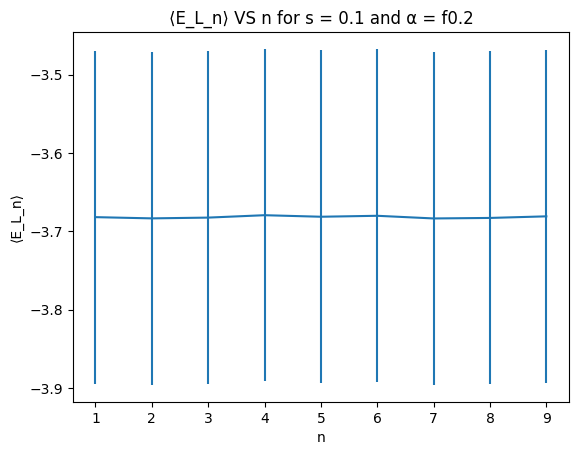

In [ ]:
A02 = 0.2
simulate_and_plot_basic(N, A02, s, k, B, n_rec)

### α = 0.3

step #9999 after equil
σ⟨ELn ⟩ after the simulation = 0.20130338248298602


([-0.0035842364671235033,
  -3.485158443221152,
  -3.4862069428290643,
  -3.486388545401975,
  -3.4883523131415317,
  -3.485615850623566,
  -3.4861850817223035,
  -3.48621671315162,
  -3.4876925836244173,
  -3.4863341852323884],
 array([0.0002135 , 0.20123663, 0.20129668, 0.20130673, 0.20141861,
        0.20126278, 0.20129459, 0.20129655, 0.20138026, 0.20130338]))

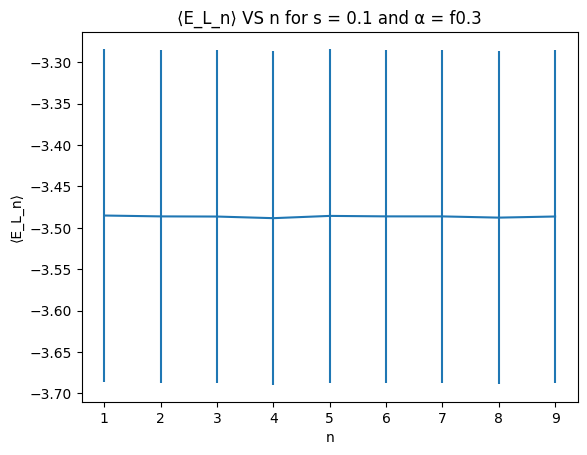

In [ ]:
A03 = 0.3
simulate_and_plot_basic(N, A03, s, k, B, n_rec)

### α = 0.4

step #9999 after equil
σ⟨ELn ⟩ after the simulation = 0.1922106139918066


([-0.0033930915616325447,
  -3.328230967832164,
  -3.32819503492165,
  -3.3287246218612125,
  -3.3287372971666747,
  -3.328088597841961,
  -3.327494846857634,
  -3.328636997264079,
  -3.327894061984094,
  -3.3281048157870763],
 array([0.00020148, 0.19222198, 0.19221678, 0.1922456 , 0.19224946,
        0.19221113, 0.19217627, 0.19223983, 0.19219912, 0.19221061]))

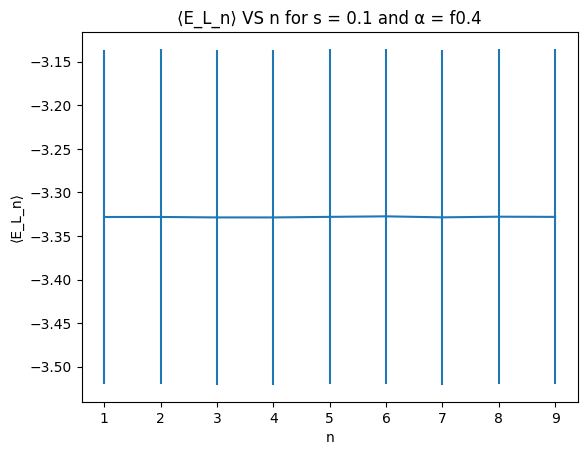

In [ ]:
A04 = 0.4
simulate_and_plot_basic(N, A04, s, k, B, n_rec)

### α = 0.5

step #9999 after equil
σ⟨ELn ⟩ after the simulation = 0.18433797618611977


([-0.0031944530245851368,
  -3.190948773904941,
  -3.189566486420552,
  -3.190890909758126,
  -3.191550480642824,
  -3.1901332749284657,
  -3.1903336557242206,
  -3.1914643718228954,
  -3.1900100172391728,
  -3.190271236448034],
 array([0.00018939, 0.18438259, 0.18430217, 0.18437646, 0.18441175,
        0.18433149, 0.18434037, 0.18440587, 0.1843225 , 0.18433798]))

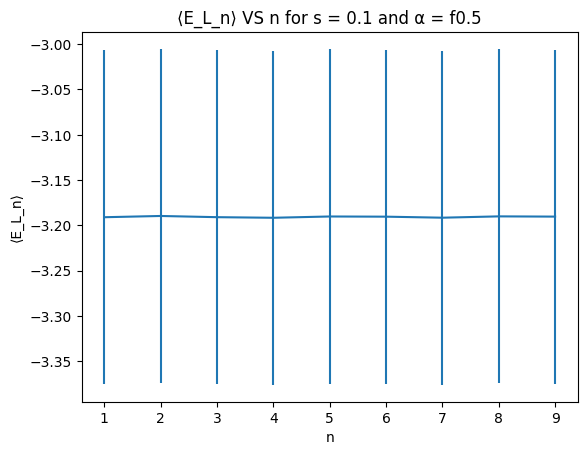

In [ ]:
A05 = 0.5
simulate_and_plot_basic(N, A05, s, k, B, n_rec)

##n equilibration = 1000

In [ ]:
n_eq = 1000

## N for c & d = 10000

In [ ]:
N = 10000

##c

Choosing α bin = 0.02

In [ ]:
n_rec = N-1
B = 0.5
k = 2

In [ ]:
A_range = np.arange(0, 0.52, 0.02)
E_l_n_total_A_range, standard_error_A_range = zip(
    *[
        simulate_excluding_equil(N, A_range[i], s, k, B, n_rec, n_eq)
        for i in range(len(A_range))
    ]
)

In [ ]:
plt.errorbar(A_range, E_l_n_total_A_range, standard_error_A_range)
plt.ylabel('⟨E_L bar⟩')
plt.xlabel('α')
plt.title(f'⟨E_L bar⟩ VS α for s = {s} and n_equil = {n_eq}')

In [ ]:
print(f'Min σ⟨E_L_n⟩ = {np.min(standard_error_A_range)}')
print(f'At α = {A_range[np.argmin(standard_error_A_range)]}')
print(f'with ⟨E_L_n⟩ = {E_l_n_total_A_range[np.argmin(standard_error_A_range)]}')

## α = 0.14

In [ ]:
A = 0.14

##d

Choosing N = 10000 as in c
and κ bin = 0.02

In [ ]:
B = 0.5

In [ ]:
k_range = np.arange(1.7,2.2+0.03,0.03)
E_l_n_total_k_range, standard_error_k_range = zip(
    *[
        simulate_excluding_equil(N, A, s, k_range[i], B, n_rec, n_eq)
        for i in range(len(k_range))
    ]
)

In [ ]:
plt.errorbar(A_range, E_l_n_total_A_range, standard_error_A_range)
plt.ylabel('⟨E_L bar⟩')
plt.xlabel('κ')
plt.title(f'⟨E_L bar⟩ VS κ for s = {s} and n_equil = {n_eq}')

In [ ]:
print(f'Min σ⟨E_L_n⟩ = {np.min(standard_error_k_range)}')
print(f'At κ = {k_range[np.argmin(standard_error_k_range)]}')
print(f'with ⟨E_L_n⟩ = {E_l_n_total_k_range[np.argmin(standard_error_k_range)]}')

##e

In [ ]:
B038 = 0.38
A018 = 0.18
k185 = 1.85
n_rec = N-1

E_l_n_total_A018_k_185_B038, standard_error_A018_k_185_B038 = simulate_excluding_equil(
    N,
    A018,
    s,
    k185,
    B038,
    n_rec,
    n_eq
)

In [ ]:
print(f'E_l_n_total_A018_k_185_B038 = {E_l_n_total_A018_k_185_B038}')
print(f'standard_error_A018_k_185_B038 = {standard_error_A018_k_185_B038}')